In [1]:
!pip install pandas numpy matplotlib seaborn openpyxl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Ready ✓")

Ready ✓


In [5]:
from google.colab import files
uploaded = files.upload()   # select Online Retail.csv

df = pd.read_csv("OnlineRetail (1).csv", encoding='latin1')
print(f"Shape: {df.shape}")
df.head()

Saving OnlineRetail.csv to OnlineRetail (2).csv
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
print("=== NULL VALUES ===")
print(df.isnull().sum())

print(f"\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum():,}")

print(f"\n=== DATA TYPES ===")
print(df.dtypes)

print(f"\n=== BASIC STATS ===")
print(df[["Quantity", "UnitPrice"]].describe().round(2))

=== NULL VALUES ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 5,268

=== DATA TYPES ===
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

=== BASIC STATS ===
        Quantity  UnitPrice
count  541909.00  541909.00
mean        9.55       4.61
std       218.08      96.76
min    -80995.00  -11062.06
25%         1.00       1.25
50%         3.00       2.08
75%        10.00       4.13
max     80995.00   38970.00


In [7]:
# Step 1 — Convert InvoiceDate to proper datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Step 2 — Drop rows with no CustomerID
df = df.dropna(subset=["CustomerID"])

# Step 3 — Remove cancellations (InvoiceNo starts with "C")
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Step 4 — Remove negative or zero Quantity and UnitPrice
df = df[df["Quantity"]  > 0]
df = df[df["UnitPrice"] > 0]

# Step 5 — Remove duplicates
df = df.drop_duplicates()

# Step 6 — Convert CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)

# Step 7 — Create TotalPrice column
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Summary
print("=== AFTER CLEANING ===")
print(f"Rows remaining  : {df.shape[0]:,}")
print(f"Rows removed    : {541909 - df.shape[0]:,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Date range      : {df['InvoiceDate'].min().date()} "
      f"to {df['InvoiceDate'].max().date()}")
print(f"\nNulls remaining:\n{df.isnull().sum()}")
print(f"\nQuantity min : {df['Quantity'].min()}")
print(f"UnitPrice min: {df['UnitPrice'].min()}")

=== AFTER CLEANING ===
Rows remaining  : 392,692
Rows removed    : 149,217
Unique customers: 4,338
Date range      : 2010-12-01 to 2011-12-09

Nulls remaining:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

Quantity min : 1
UnitPrice min: 0.001


In [8]:
# Snapshot date = one day after the last transaction
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

# Calculate R, F, M for every customer
rfm = df.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate",
                 lambda x: (snapshot_date - x.max()).days),
    Frequency = ("InvoiceNo",   "nunique"),
    Monetary  = ("TotalPrice",  "sum")
).reset_index()

# Round Monetary to 2 decimal places
rfm["Monetary"] = rfm["Monetary"].round(2)

print(f"\n=== RFM TABLE (first 5 rows) ===")
print(rfm.head().to_string(index=False))

print(f"\n=== RFM SUMMARY STATS ===")
print(rfm[["Recency","Frequency","Monetary"]].describe().round(2))

Snapshot date: 2011-12-10

=== RFM TABLE (first 5 rows) ===
 CustomerID  Recency  Frequency  Monetary
      12346      326          1  77183.60
      12347        2          7   4310.00
      12348       75          4   1797.24
      12349       19          1   1757.55
      12350      310          1    334.40

=== RFM SUMMARY STATS ===
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


In [9]:
# R score — lower recency = better = higher score
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=4, labels=[4, 3, 2, 1]   # reversed — recent buyers get 4
)

# F score — higher frequency = better = higher score
# rank(method='first') handles duplicate values
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=4, labels=[1, 2, 3, 4]
)

# M score — higher spend = better = higher score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=4, labels=[1, 2, 3, 4]
)

# Combined RFM string score e.g. "444" or "112"
rfm["RFM_Score"] = (rfm["R_Score"].astype(str) +
                    rfm["F_Score"].astype(str) +
                    rfm["M_Score"].astype(str))

print("=== SCORED RFM TABLE (first 5 rows) ===")
print(rfm[["CustomerID","Recency","Frequency","Monetary",
           "R_Score","F_Score","M_Score","RFM_Score"
           ]].head().to_string(index=False))

=== SCORED RFM TABLE (first 5 rows) ===
 CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
      12346      326          1  77183.60       1       1       4       114
      12347        2          7   4310.00       4       4       4       444
      12348       75          4   1797.24       2       3       4       234
      12349       19          1   1757.55       3       1       4       314
      12350      310          1    334.40       1       1       2       112


In [10]:
def assign_segment(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champion"
    elif r >= 3 and f >= 3:
        return "Loyal"
    elif r >= 3 and f <= 2:
        return "Promising"
    elif r == 2 and f >= 2:
        return "At Risk"
    elif r <= 2 and f <= 2 and m >= 3:
        return "Cant Lose"
    else:
        return "Lost"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

print("=== SEGMENT DISTRIBUTION ===")
seg_counts = rfm["Segment"].value_counts()
seg_pct    = rfm["Segment"].value_counts(normalize=True).mul(100).round(1)

summary = pd.DataFrame({
    "Customers" : seg_counts,
    "Percentage": seg_pct.map(lambda x: f"{x}%")
})
print(summary.to_string())

=== SEGMENT DISTRIBUTION ===
           Customers Percentage
Segment                        
Lost            1218      28.1%
Loyal           1034      23.8%
At Risk          759      17.5%
Promising        665      15.3%
Champion         489      11.3%
Cant Lose        173       4.0%


### RFM Segment Analysis — Key Findings

| Segment | Customers | % of Base | Priority |
|---|---|---|---|
| Champion | 489 | 11.3% | Retain & reward |
| Loyal | 1,034 | 23.8% | Nurture & upsell |
| Promising | 665 | 15.3% | Convert to Loyal |
| At Risk | 759 | 17.5% | Win-back campaign |
| Cant Lose | 173 | 4.0% | Urgent re-engagement |
| Lost | 1,218 | 28.1% | Low-cost reactivation |

**Critical insight:** Lost customers are the largest segment (28.1%).
Average customer recency is 92 days — indicating significant
drop-off in repeat purchase behaviour across the customer base.

In [11]:
# LTV per customer — total revenue, orders, avg order value
ltv = df.groupby("CustomerID").agg(
    total_revenue   = ("TotalPrice", "sum"),
    total_orders    = ("InvoiceNo",  "nunique"),
    avg_order_value = ("TotalPrice", "mean"),
).round(2).reset_index()

# Merge LTV into RFM table
rfm = rfm.merge(ltv, on="CustomerID", how="left")

print("=== LTV MERGED INTO RFM ===")
print(rfm[["CustomerID","Segment","total_revenue",
           "total_orders","avg_order_value"]
          ].head(8).to_string(index=False))

=== LTV MERGED INTO RFM ===
 CustomerID   Segment  total_revenue  total_orders  avg_order_value
      12346 Cant Lose       77183.60             1         77183.60
      12347  Champion        4310.00             7            23.68
      12348   At Risk        1797.24             4            57.98
      12349 Promising        1757.55             1            24.08
      12350      Lost         334.40             1            19.67
      12352     Loyal        2506.04             8            29.48
      12353      Lost          89.00             1            22.25
      12354 Cant Lose        1079.40             1            18.61


In [12]:
seg_ltv = rfm.groupby("Segment").agg(
    customers       = ("CustomerID",      "count"),
    avg_ltv         = ("total_revenue",   "mean"),
    total_revenue   = ("total_revenue",   "sum"),
    avg_orders      = ("total_orders",    "mean"),
    avg_order_value = ("avg_order_value", "mean"),
).round(2).sort_values("avg_ltv", ascending=False)

# Add revenue share %
seg_ltv["rev_share"] = (
    seg_ltv["total_revenue"] /
    seg_ltv["total_revenue"].sum() * 100
).round(1).map(lambda x: f"{x}%")

print("=== LTV BY SEGMENT ===")
print(seg_ltv.to_string())

=== LTV BY SEGMENT ===
           customers  avg_ltv  total_revenue  avg_orders  avg_order_value rev_share
Segment                                                                            
Champion         489  9047.80     4424373.61       15.53            38.14     49.8%
Loyal           1034  2088.74     2159756.49        5.22            28.96     24.3%
Cant Lose        173  1729.94      299278.95        1.37           533.90      3.4%
At Risk          759  1255.39      952843.70        3.30            37.30     10.7%
Promising        665   751.28      499604.37        1.45           113.96      5.6%
Lost            1218   452.67      551351.77        1.50            42.36      6.2%


### LTV by Segment — Key Findings

| Segment | Customers | Avg LTV | Revenue Share |
|---|---|---|---|
| Champion | 489 (11.3%) | £9,047 | **49.8%** |
| Loyal | 1,034 (23.8%) | £2,088 | 24.3% |
| At Risk | 759 (17.5%) | £1,255 | 10.7% |
| Lost | 1,218 (28.1%) | £452 | 6.2% |
| Promising | 665 (15.3%) | £751 | 5.6% |
| Cant Lose | 173 (4.0%) | £1,729 | 3.4% |

**Critical insight 1:** Champions represent only 11.3% of the customer
base but generate 49.8% of total revenue. Losing this segment would
be catastrophic for the business.

**Critical insight 2:** Champions + Loyal (35.1% of customers)
account for 74.1% of all revenue. The business depends on 1,523 people.

**Critical insight 3:** 932 At Risk + Cant Lose customers with avg LTV
of £1,300+ represent recoverable high-value revenue if re-engaged now.

In [13]:
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titleweight" : "bold",
    "axes.titlesize"   : 13,
    "figure.dpi"       : 130,
})

SEG_COLORS = {
    "Champion" : "#1a5276",
    "Loyal"    : "#2e86c1",
    "Promising": "#1d8348",
    "At Risk"  : "#d4ac0d",
    "Cant Lose": "#ca6f1e",
    "Lost"     : "#a93226",
}

SEG_ORDER = ["Champion","Loyal","Promising",
             "At Risk","Cant Lose","Lost"]

print("Style ready ✓")

Style ready ✓


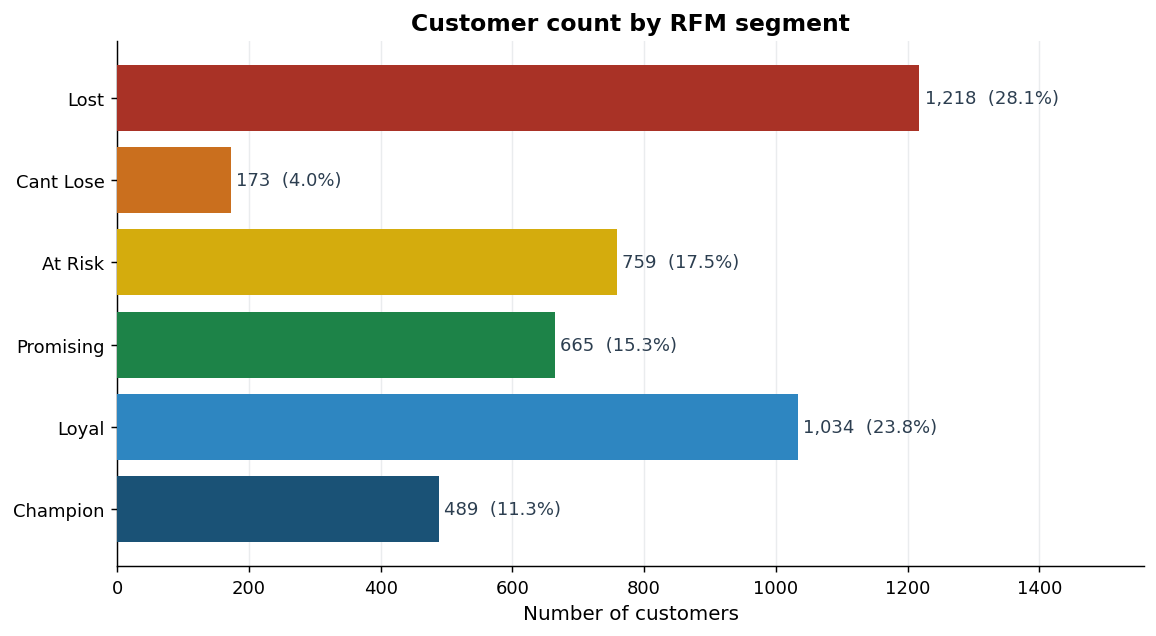

Chart 1 saved ✓


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

# Sort by our defined order
seg_data = rfm["Segment"].value_counts().reindex(SEG_ORDER)
colors   = [SEG_COLORS[s] for s in SEG_ORDER]

bars = ax.barh(SEG_ORDER, seg_data.values,
               color=colors, zorder=3)

# Value labels on each bar
for bar, val, pct in zip(bars,
                          seg_data.values,
                          seg_data.values / seg_data.sum() * 100):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{val:,}  ({pct:.1f}%)",
            va="center", fontsize=10, color="#2c3e50")

ax.set_xlabel("Number of customers", fontsize=11)
ax.set_title("Customer count by RFM segment", fontweight="bold")
ax.set_xlim(0, seg_data.max() * 1.28)
ax.grid(axis="x", color="#eaecee", linewidth=0.8, zorder=0)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart1_segment_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved ✓")

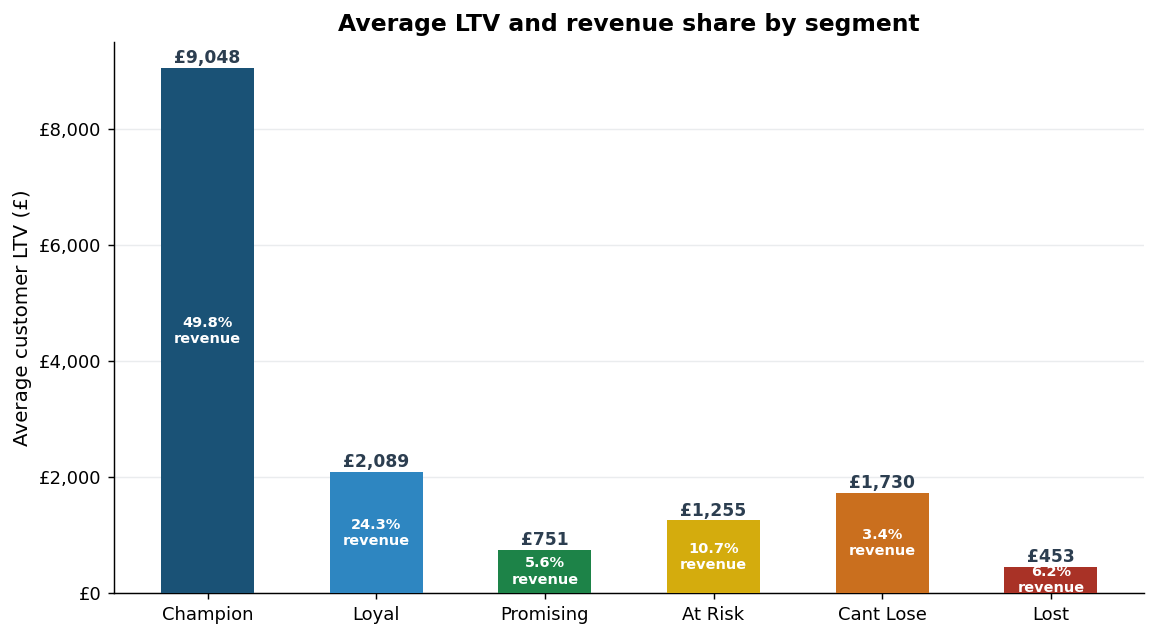

Chart 2 saved ✓


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

# Use seg_ltv we already calculated
ltv_data = seg_ltv["avg_ltv"].reindex(SEG_ORDER)
colors   = [SEG_COLORS[s] for s in SEG_ORDER]

bars = ax.bar(SEG_ORDER, ltv_data.values,
              color=colors, width=0.55, zorder=3)

# Value labels on top of bars
for bar, val in zip(bars, ltv_data.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 80,
            f"£{val:,.0f}",
            ha="center", fontsize=9.5,
            fontweight="bold", color="#2c3e50")

# Revenue share annotation
for bar, seg in zip(bars, SEG_ORDER):
    share = seg_ltv.loc[seg, "rev_share"]
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            f"{share}\nrevenue",
            ha="center", va="center",
            fontsize=8, color="white",
            fontweight="bold")

ax.set_ylabel("Average customer LTV (£)", fontsize=11)
ax.set_title("Average LTV and revenue share by segment",
             fontweight="bold")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"£{int(y):,}"))
ax.grid(axis="y", color="#eaecee", linewidth=0.8, zorder=0)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart2_ltv_by_segment.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved ✓")

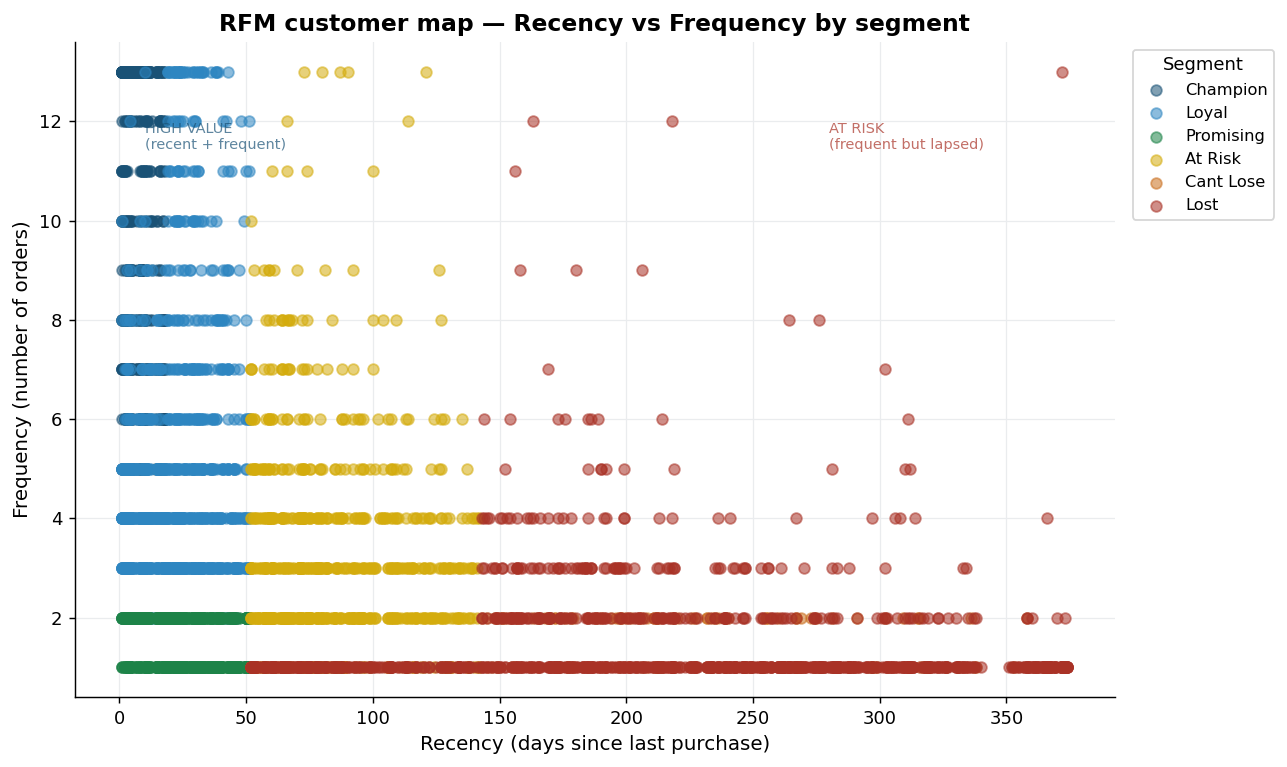

Chart 3 saved ✓


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Cap frequency outliers at 95th percentile for cleaner visual
freq_cap = rfm["Frequency"].quantile(0.95)
plot_df  = rfm.copy()
plot_df["Frequency"] = plot_df["Frequency"].clip(upper=freq_cap)

for seg in SEG_ORDER:
    seg_df = plot_df[plot_df["Segment"] == seg]
    ax.scatter(
        seg_df["Recency"],
        seg_df["Frequency"],
        c     = SEG_COLORS[seg],
        label = seg,
        alpha = 0.55,
        s     = 35,
        zorder= 3
    )

ax.set_xlabel("Recency (days since last purchase)", fontsize=11)
ax.set_ylabel("Frequency (number of orders)", fontsize=11)
ax.set_title("RFM customer map — Recency vs Frequency by segment",
             fontweight="bold")
ax.legend(title="Segment", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9)
ax.grid(color="#eaecee", linewidth=0.7, zorder=0)
ax.set_facecolor("white")

# Quadrant labels
ax.text(10,  freq_cap * 0.88, "HIGH VALUE\n(recent + frequent)",
        fontsize=8, color="#1a5276", alpha=0.7)
ax.text(280, freq_cap * 0.88, "AT RISK\n(frequent but lapsed)",
        fontsize=8, color="#a93226", alpha=0.7)

plt.tight_layout()
plt.savefig("chart3_rfm_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved ✓")

In [17]:
# Step 1 — Create invoice month column
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

# Step 2 — Find each customer's first purchase month
cohort_df = df.groupby("CustomerID")["InvoiceMonth"] \
              .min().reset_index()
cohort_df.columns = ["CustomerID", "CohortMonth"]

# Step 3 — Merge cohort month back to main dataframe
df = df.merge(cohort_df, on="CustomerID", how="left")

# Step 4 — Calculate cohort index (months since first purchase)
df["CohortIndex"] = (
    df["InvoiceMonth"].dt.year * 12 + df["InvoiceMonth"].dt.month
) - (
    df["CohortMonth"].dt.year  * 12 + df["CohortMonth"].dt.month
)

# Step 5 — Count unique customers per cohort per month
cohort_counts = df.groupby(
    ["CohortMonth", "CohortIndex"]
)["CustomerID"].nunique().reset_index()

# Step 6 — Pivot into a matrix
cohort_pivot = cohort_counts.pivot_table(
    index   = "CohortMonth",
    columns = "CohortIndex",
    values  = "CustomerID"
)

# Step 7 — Divide every row by its cohort size (column 0)
cohort_size      = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3)

print("Cohort retention matrix:")
print(retention_matrix.iloc[:, :6].to_string())

Cohort retention matrix:
CohortIndex    0      1      2      3      4      5
CohortMonth                                        
2010-12      1.0  0.366  0.323  0.384  0.363  0.398
2011-01      1.0  0.221  0.266  0.230  0.321  0.288
2011-02      1.0  0.187  0.187  0.284  0.271  0.247
2011-03      1.0  0.150  0.252  0.199  0.223  0.168
2011-04      1.0  0.213  0.203  0.210  0.197  0.227
2011-05      1.0  0.190  0.173  0.173  0.208  0.232
2011-06      1.0  0.174  0.157  0.264  0.231  0.335
2011-07      1.0  0.181  0.207  0.223  0.271  0.112
2011-08      1.0  0.207  0.249  0.243  0.124    NaN
2011-09      1.0  0.234  0.301  0.114    NaN    NaN
2011-10      1.0  0.240  0.115    NaN    NaN    NaN
2011-11      1.0  0.111    NaN    NaN    NaN    NaN
2011-12      1.0    NaN    NaN    NaN    NaN    NaN


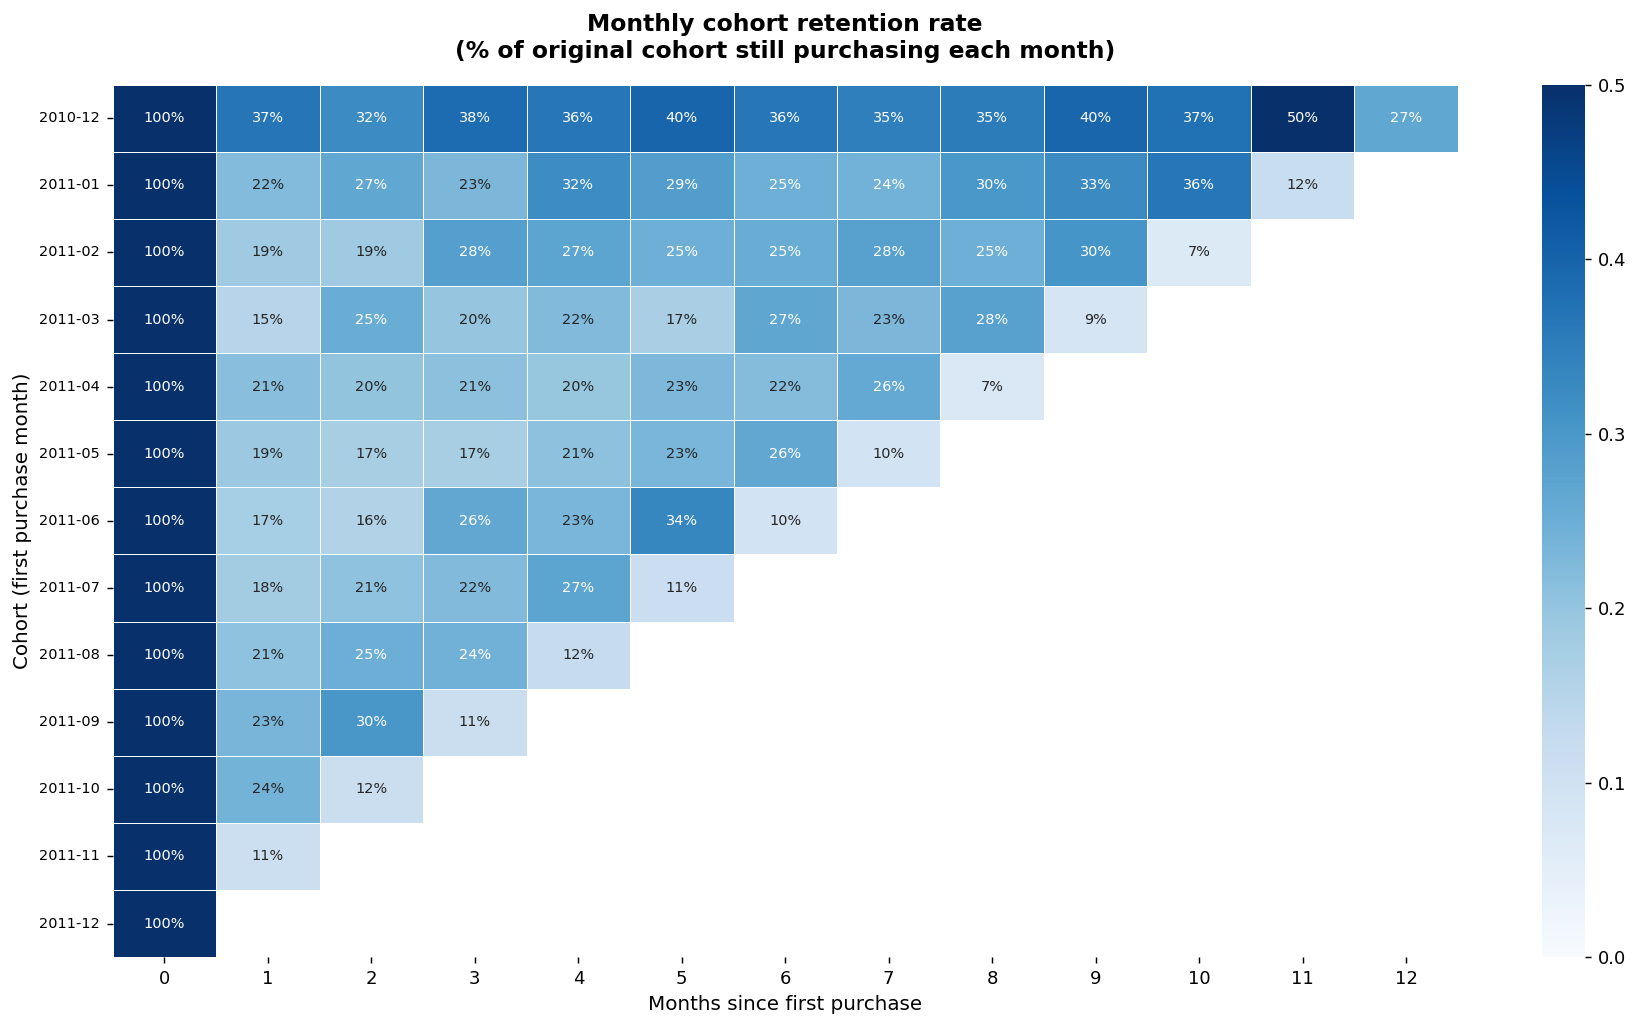

Chart 4 saved ✓


In [18]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    retention_matrix,
    annot      = True,
    fmt        = ".0%",
    cmap       = "Blues",
    linewidths = 0.5,
    linecolor  = "white",
    ax         = ax,
    annot_kws  = {"size": 8},
    vmin       = 0,
    vmax       = 0.5
)

ax.set_title("Monthly cohort retention rate\n"
             "(% of original cohort still purchasing each month)",
             fontweight="bold", fontsize=13, pad=15)
ax.set_xlabel("Months since first purchase", fontsize=11)
ax.set_ylabel("Cohort (first purchase month)", fontsize=11)
ax.set_yticklabels(
    [str(label) for label in retention_matrix.index],
    rotation=0, fontsize=8
)

plt.tight_layout()
plt.savefig("chart4_cohort_retention.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved ✓")

### Cohort Retention Analysis — Key Findings

**Overall retention is poor but consistent:**
- Average month-1 retention across all cohorts: ~20%
- This means 80% of new customers never make a second purchase

**December 2010 cohort is the strongest:**
- Retains 35-40% consistently across 12 months
- Likely contains wholesale/trade buyers with regular order cycles

**Critical business problem:**
- The sharp drop after month 0 → month 1 across every cohort
  signals a broken post-purchase journey
- A targeted first-repeat-purchase campaign could have
  significant revenue impact
  
**Recommendation:** Priority intervention should target customers
in months 1-2 after their first purchase — this is where the
business loses the most people.

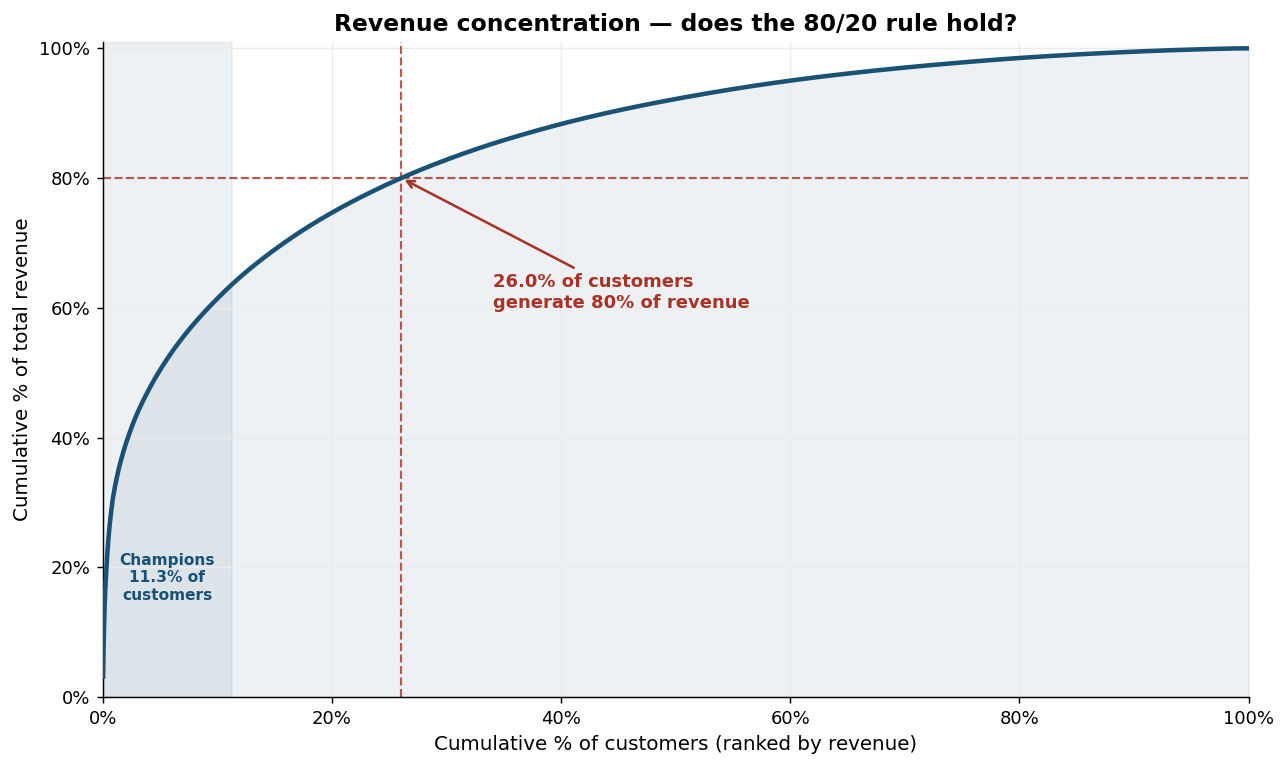

Chart 5 saved ✓

80% of revenue comes from top 26.0% of customers


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort customers by LTV descending
sorted_ltv = rfm["total_revenue"].sort_values(
    ascending=False
).reset_index(drop=True)

# Cumulative revenue percentage
cumulative_rev = sorted_ltv.cumsum() / sorted_ltv.sum() * 100

# Customer percentage
customer_pct = (sorted_ltv.index + 1) / len(sorted_ltv) * 100

# ── Main line ─────────────────────────────────────────────────
ax.plot(customer_pct, cumulative_rev,
        color="#1a5276", linewidth=2.5, zorder=3)

ax.fill_between(customer_pct, cumulative_rev,
                alpha=0.08, color="#1a5276")

# ── Find the 80% revenue point ────────────────────────────────
idx_80  = (cumulative_rev >= 80).idxmax()
cust_80 = customer_pct[idx_80]

# ── Reference lines ───────────────────────────────────────────
ax.axhline(80, color="#a93226", linewidth=1.2,
           linestyle="--", alpha=0.8)
ax.axvline(cust_80, color="#a93226", linewidth=1.2,
           linestyle="--", alpha=0.8)

# ── Annotation ────────────────────────────────────────────────
ax.annotate(
    f"{cust_80:.1f}% of customers\ngenerate 80% of revenue",
    xy=(cust_80, 80),
    xytext=(cust_80 + 8, 60),
    fontsize=10, color="#a93226", fontweight="bold",
    arrowprops=dict(arrowstyle="->",
                    color="#a93226", lw=1.4)
)

# ── Champion zone ─────────────────────────────────────────────
champ_pct = rfm[rfm["Segment"]=="Champion"].shape[0] \
            / len(rfm) * 100
ax.axvspan(0, champ_pct, alpha=0.08,
           color="#1a5276", label=f"Champions ({champ_pct:.1f}%)")

ax.text(champ_pct / 2, 15,
        f"Champions\n{champ_pct:.1f}% of\ncustomers",
        ha="center", fontsize=8.5,
        color="#1a5276", fontweight="bold")

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel("Cumulative % of customers (ranked by revenue)",
              fontsize=11)
ax.set_ylabel("Cumulative % of total revenue", fontsize=11)
ax.set_title("Revenue concentration — does the 80/20 rule hold?",
             fontweight="bold")
ax.set_xlim(0, 100)
ax.set_ylim(0, 101)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x)}%"))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{int(y)}%"))
ax.grid(color="#eaecee", linewidth=0.8, zorder=0)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart5_pareto_revenue.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved ✓")
print(f"\n80% of revenue comes from top {cust_80:.1f}% of customers")

### Revenue Concentration — Key Finding

**The 80/20 rule does not hold here — reality is more extreme.**

Only **26% of customers generate 80% of total revenue.**

| Threshold | Customers needed |
|---|---|
| First 50% of revenue | top 6% of customers |
| First 80% of revenue | top 26% of customers |
| First 100% of revenue | all 100% of customers |

Champions alone (11.3% of customers) account for nearly 50% of
all revenue. This level of concentration creates significant
business risk — losing even a fraction of the top customer
segment would have a disproportionate impact on total revenue.

In [20]:
campaigns = {
    "Segment"   : ["Champion", "Loyal", "Promising",
                   "At Risk",  "Cant Lose", "Lost"],
    "Size"      : [489, 1034, 665, 759, 173, 1218],
    "Avg LTV"   : ["£9,048", "£2,089", "£751",
                   "£1,255", "£1,730", "£453"],
    "Action"    : [
        "VIP programme · early product access · referral ask",
        "Loyalty rewards · upsell to higher spend tier",
        "First repeat purchase incentive · onboarding series",
        "Win-back campaign · personalised discount",
        "Urgent re-engagement · deep discount · personal outreach",
        "Low-cost email reactivation · accept likely churn",
    ],
    "Priority"  : ["🔴 Protect", "🟡 Grow", "🟢 Convert",
                   "🔴 Recover", "🔴 Urgent", "⚪ Low cost"],
}

campaign_df = pd.DataFrame(campaigns)
print("=== CAMPAIGN RECOMMENDATIONS BY SEGMENT ===\n")
print(campaign_df.to_string(index=False))

=== CAMPAIGN RECOMMENDATIONS BY SEGMENT ===

  Segment  Size Avg LTV                                                   Action   Priority
 Champion   489  £9,048      VIP programme · early product access · referral ask  🔴 Protect
    Loyal  1034  £2,089            Loyalty rewards · upsell to higher spend tier     🟡 Grow
Promising   665    £751      First repeat purchase incentive · onboarding series  🟢 Convert
  At Risk   759  £1,255                Win-back campaign · personalised discount  🔴 Recover
Cant Lose   173  £1,730 Urgent re-engagement · deep discount · personal outreach   🔴 Urgent
     Lost  1218    £453        Low-cost email reactivation · accept likely churn ⚪ Low cost


---

## Final Recommendation

### The business problem in one sentence
26% of customers generate 80% of revenue — and 28% of the
customer base has already been lost.

---

### Five actions for the marketing team

**1. Protect Champions immediately (489 customers · £4.4M revenue)**  
Launch a VIP programme — exclusive early access, personal account
managers, referral incentives. Losing 10% of Champions costs more
than winning back the entire Lost segment.

**2. Accelerate Loyal → Champion conversion (1,034 customers)**  
Loyal customers average 5.2 orders vs Champions at 15.5. A targeted
high-frequency purchase incentive could move the best Loyal customers
into the Champion tier within 6 months.

**3. Fix the post-purchase journey (all new customers)**  
Cohort analysis shows 80% of new customers never make a second
purchase. A structured month-1 re-engagement email sequence —
personalised product recommendations, first repeat purchase discount —
is the single highest-ROI intervention available.

**4. Recover At Risk customers now (759 customers · £1,255 avg LTV)**  
These customers used to buy regularly. A time-limited win-back
offer sent within the next 30 days will reach them before they
fully disengage. Expected recovery rate: 15-25%.

**5. Deprioritise broad acquisition until retention is fixed**  
Acquiring new customers into a broken post-purchase journey wastes
budget. The data shows the retention problem starts at month 1,
not at acquisition. Fix the leaky bucket before adding more water.

---

### Revenue opportunity summary

| Action | Segment | Potential impact |
|---|---|---|
| Retain 90% of Champions | 489 customers | Protect £4.4M / year |
| Convert 20% of Loyal to Champion | ~207 customers | +£1.4M LTV uplift |
| Improve month-1 retention by 5pp | all new cohorts | Compounding effect |
| Recover 20% of At Risk | ~152 customers | +£190K revenue |

---

### Tools used
Python · Pandas · Matplotlib · Seaborn · Google Colab

### Dataset
UK Online Retail Dataset — UCI Machine Learning Repository  
541,909 transactions · 4,338 customers after cleaning

In [21]:
from google.colab import files

print("=" * 50)
print("  PROJECT COMPLETE")
print("=" * 50)
print()
print("  Charts saved:")
print("  ✓ chart1_segment_distribution.png")
print("  ✓ chart2_ltv_by_segment.png")
print("  ✓ chart3_rfm_scatter.png")
print("  ✓ chart4_cohort_retention.png")
print("  ✓ chart5_pareto_revenue.png")
print()
print("  Key findings:")
print(f"  Customers analysed : 4,338")
print(f"  Champions revenue  : 49.8% of total")
print(f"  80% revenue from   : top 26% of customers")
print(f"  Month-1 retention  : ~20% average")
print(f"  Lost segment       : 28.1% of base")
print("=" * 50)

# Download all charts
for chart in ["chart1_segment_distribution.png",
              "chart2_ltv_by_segment.png",
              "chart3_rfm_scatter.png",
              "chart4_cohort_retention.png",
              "chart5_pareto_revenue.png"]:
    files.download(chart)

  PROJECT COMPLETE

  Charts saved:
  ✓ chart1_segment_distribution.png
  ✓ chart2_ltv_by_segment.png
  ✓ chart3_rfm_scatter.png
  ✓ chart4_cohort_retention.png
  ✓ chart5_pareto_revenue.png

  Key findings:
  Customers analysed : 4,338
  Champions revenue  : 49.8% of total
  80% revenue from   : top 26% of customers
  Month-1 retention  : ~20% average
  Lost segment       : 28.1% of base


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>